# CrossModal Alignment

We will use
- Flickr8k + a small CNN image encoder + a small text encoder + contrastive loss.

Here is how the complete pipline would look like:-

                  Flickr8k
                     │
          ┌──────────┴──────────┐
          ↓                     ↓
       Images                Captions
          │                     │
     CNN Encoder          Text Encoder
          │                     │
     Image Embedding      Text Embedding
          │                     │
          └──────────┬──────────┘
                     ↓
              Normalize vectors
                     ↓
             Cosine similarity
                     ↓
          Contrastive / InfoNCE Loss
                     ↓
             Shared embedding
                     │
          ┌──────────┴──────────┐
          ↓                     ↓
    Image → Text           Text → Image
     Retrieval              Retrieval
          │                     │
          └──────────┬──────────┘
                     ↓
             R@1 / R@5 / R@10

In [ ]:
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup complete")

Setup complete


In [ ]:
import os

print(os.listdir("/content")[:20])

['.config', 'encoded_train_images.pkl', 'CrowdFlowerAnnotations.txt', 'readme.txt', 'Flickr_8k.trainImages.txt', 'Flickr_8k.devImages.txt', 'Flickr8k_Dataset.zip', 'Flickr_8k.testImages.txt', 'ExpertAnnotations.txt', 'descriptions.txt', 'Flickr8k.lemma.token.txt', 'Flickr8k.token.txt', 'encoded_test_images.pkl', 'sample_data']


In [ ]:
!unzip -q Flickr8k_Dataset.zip

In [ ]:
import os

IMAGE_DIR = "/content/Flicker8k_Dataset"

print("Images:", len(os.listdir(IMAGE_DIR)))
print(os.listdir(IMAGE_DIR)[:5])

Images: 8091
['3130093622_362f32f2bb.jpg', '599366440_a238e805cf.jpg', '3739833689_a0038545bd.jpg', '2090386465_b6ebb7df2c.jpg', '1232148178_4f45cc3284.jpg']


In [ ]:
import pandas as pd
import pickle

rows = []

with open("/content/Flickr8k.token.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line or " " not in line:
            continue

        image_id, caption = line.split(" ", 1)
        image_id = image_id.split("#")[0]

        rows.append([image_id, caption])

captions = pd.DataFrame(rows, columns=["image", "caption"])

print("Captions:", len(captions))
print("Images:", captions["image"].nunique())
print(captions.head())

Captions: 40458
Images: 8092
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  child in a pink dress is climbing up a set of ...  
1                girl going into a wooden building .  
2     little girl climbing into a wooden playhouse .  
3  little girl climbing the stairs to her playhou...  
4  little girl in a pink dress going into a woode...  


In [ ]:
def load_split(path):
    with open(path, "r") as f:
        return [x.strip() for x in f if x.strip()]

train_images = load_split("/content/Flickr_8k.trainImages.txt")
val_images   = load_split("/content/Flickr_8k.devImages.txt")
test_images  = load_split("/content/Flickr_8k.testImages.txt")

train_df = captions[captions["image"].isin(train_images)].reset_index(drop=True)
val_df   = captions[captions["image"].isin(val_images)].reset_index(drop=True)
test_df  = captions[captions["image"].isin(test_images)].reset_index(drop=True)

print("TRAIN:", train_df.shape, train_df["image"].nunique())
print("VAL:", val_df.shape, val_df["image"].nunique())
print("TEST:", test_df.shape, test_df["image"].nunique())

TRAIN: (30000, 2) 6000
VAL: (5000, 2) 1000
TEST: (5000, 2) 1000


In [ ]:
import pickle
import numpy as np

with open("/content/encoded_train_images.pkl", "rb") as f:
    train_features = pickle.load(f)

with open("/content/encoded_test_images.pkl", "rb") as f:
    test_features = pickle.load(f)

print("TRAIN TYPE:", type(train_features))
print("TEST TYPE:", type(test_features))

if isinstance(train_features, dict):
    print("Train keys:", list(train_features.keys())[:5])
    first_key = list(train_features.keys())[0]
    print("First key:", first_key)
    print("First feature shape:", np.array(train_features[first_key]).shape)

elif isinstance(train_features, (list, tuple)):
    print("Train length:", len(train_features))
    print("First feature shape:", np.array(train_features[0]).shape)

else:
    print("Train shape:", np.array(train_features).shape)

print("Test shape/length:", np.array(test_features).shape if hasattr(test_features, "shape") else len(test_features))

TRAIN TYPE: <class 'dict'>
TEST TYPE: <class 'dict'>
Train keys: ['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg']
First key: 1000268201_693b08cb0e.jpg
First feature shape: (2048,)
Test shape/length: 1000


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import numpy as np

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# 1. BUILD VOCABULARY
# ============================================================

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

counter = Counter()

for caption in train_df["caption"]:
    counter.update(tokenize(caption))

# Keep most common words
MAX_VOCAB = 10000

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in counter.most_common(MAX_VOCAB - 2):
    word2idx[word] = len(word2idx)

print("Vocabulary size:", len(word2idx))


# ============================================================
# 2. ENCODE CAPTIONS
# ============================================================

MAX_LEN = 25

def encode_caption(text):
    tokens = tokenize(text)

    ids = [
        word2idx.get(token, word2idx["<UNK>"])
        for token in tokens[:MAX_LEN]
    ]

    # padding
    ids += [word2idx["<PAD>"]] * (MAX_LEN - len(ids))

    return ids


# ============================================================
# 3. DATASET
# ============================================================

class FlickrDataset(Dataset):

    def __init__(self, dataframe, feature_dict):
        self.df = dataframe.reset_index(drop=True)
        self.features = feature_dict

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_name = row["image"]
        caption = row["caption"]

        image_feature = self.features[image_name]

        image_feature = torch.tensor(
            image_feature,
            dtype=torch.float32
        )

        caption_ids = torch.tensor(
            encode_caption(caption),
            dtype=torch.long
        )

        return image_feature, caption_ids


train_dataset = FlickrDataset(
    train_df,
    train_features
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Training samples:", len(train_dataset))


# ============================================================
# 4. MODEL
# ============================================================

class CrossModalModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=256
    ):

        super().__init__()

        # IMAGE ENCODER
        self.image_encoder = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, embed_dim)
        )

        # TEXT ENCODER
        self.embedding = nn.Embedding(
            vocab_size,
            128,
            padding_idx=0
        )

        self.text_encoder = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

        # temperature
        self.logit_scale = nn.Parameter(
            torch.tensor(np.log(1 / 0.07))
        )

    def encode_image(self, x):

        x = self.image_encoder(x)

        return nn.functional.normalize(
            x,
            dim=1
        )

    def encode_text(self, tokens):

        mask = (tokens != 0).float()

        x = self.embedding(tokens)

        # mean pooling
        x = (x * mask.unsqueeze(-1)).sum(dim=1)

        lengths = mask.sum(dim=1).clamp(min=1)

        x = x / lengths.unsqueeze(-1)

        x = self.text_encoder(x)

        return nn.functional.normalize(
            x,
            dim=1
        )

    def forward(self, images, captions):

        image_emb = self.encode_image(images)

        text_emb = self.encode_text(captions)

        return image_emb, text_emb


model = CrossModalModel(
    vocab_size=len(word2idx)
).to(device)


# ============================================================
# 5. CONTRASTIVE LOSS
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()


# ============================================================
# 6. TRAIN
# ============================================================

EPOCHS = 5

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, captions in train_loader:

        images = images.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()

        image_emb, text_emb = model(
            images,
            captions
        )

        # similarity matrix
        scale = model.logit_scale.exp().clamp(
            max=100
        )

        logits = scale * image_emb @ text_emb.T

        # matching pair is diagonal
        labels = torch.arange(
            len(images),
            device=device
        )

        # image -> text
        loss_i = criterion(
            logits,
            labels
        )

        # text -> image
        loss_t = criterion(
            logits.T,
            labels
        )

        loss = (loss_i + loss_t) / 2

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"| Loss: {avg_loss:.4f}"
    )

print("Training complete!")

Device: cpu
Vocabulary size: 7560
Training samples: 30000


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/5 | Loss: 4.1226
Epoch 2/5 | Loss: 2.9472
Epoch 3/5 | Loss: 2.2786
Epoch 4/5 | Loss: 1.8020
Epoch 5/5 | Loss: 1.4382
Training complete!


In [ ]:
import torch
import numpy as np
from collections import defaultdict

model.eval()

# -------------------------------------------------
# 1. Create ONE caption per test image for evaluation
# -------------------------------------------------
# We use the first caption as the query caption.
# All 5 captions remain valid targets during evaluation.

test_image_names = test_images

# -------------------------------------------------
# 2. Encode all test images
# -------------------------------------------------

image_embeddings = []

for image_name in test_image_names:
    feature = torch.tensor(
        test_features[image_name],
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_image(feature)

    image_embeddings.append(emb.cpu())

image_embeddings = torch.cat(image_embeddings)

print("Image embeddings:", image_embeddings.shape)


# -------------------------------------------------
# 3. Encode all test captions
# -------------------------------------------------

test_caption_embeddings = []
caption_image_names = []

for _, row in test_df.iterrows():

    tokens = torch.tensor(
        encode_caption(row["caption"]),
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_text(tokens)

    test_caption_embeddings.append(emb.cpu())
    caption_image_names.append(row["image"])

test_caption_embeddings = torch.cat(test_caption_embeddings)

print("Caption embeddings:", test_caption_embeddings.shape)


# -------------------------------------------------
# 4. Similarity matrix
# -------------------------------------------------

similarity = image_embeddings @ test_caption_embeddings.T

print("Similarity matrix:", similarity.shape)


# -------------------------------------------------
# 5. Image -> Text Recall
# -------------------------------------------------

def image_to_text_recall(similarity, k):

    correct = 0

    for i, image_name in enumerate(test_image_names):

        scores = similarity[i]

        top_k = torch.topk(
            scores,
            k=k
        ).indices.numpy()

        retrieved_images = [
            caption_image_names[j]
            for j in top_k
        ]

        if image_name in retrieved_images:
            correct += 1

    return correct / len(test_image_names)


# -------------------------------------------------
# 6. Text -> Image Recall
# -------------------------------------------------

def text_to_image_recall(similarity, k):

    correct = 0

    # each caption corresponds to one image
    for j, image_name in enumerate(caption_image_names):

        scores = similarity[:, j]

        top_k = torch.topk(
            scores,
            k=k
        ).indices.numpy()

        retrieved_images = [
            test_image_names[i]
            for i in top_k
        ]

        if image_name in retrieved_images:
            correct += 1

    return correct / len(caption_image_names)


# -------------------------------------------------
# 7. Calculate metrics
# -------------------------------------------------

print("\nIMAGE → TEXT")

for k in [1, 5, 10]:

    r = image_to_text_recall(
        similarity,
        k
    )

    print(f"Recall@{k}: {r:.4f} ({r*100:.2f}%)")


print("\nTEXT → IMAGE")

for k in [1, 5, 10]:

    r = text_to_image_recall(
        similarity,
        k
    )

    print(f"Recall@{k}: {r:.4f} ({r*100:.2f}%)")


Image embeddings: torch.Size([1000, 256])
Caption embeddings: torch.Size([5000, 256])
Similarity matrix: torch.Size([1000, 5000])

IMAGE → TEXT
Recall@1: 0.1190 (11.90%)
Recall@5: 0.3160 (31.60%)
Recall@10: 0.4370 (43.70%)

TEXT → IMAGE
Recall@1: 0.0876 (8.76%)
Recall@5: 0.2672 (26.72%)
Recall@10: 0.3878 (38.78%)


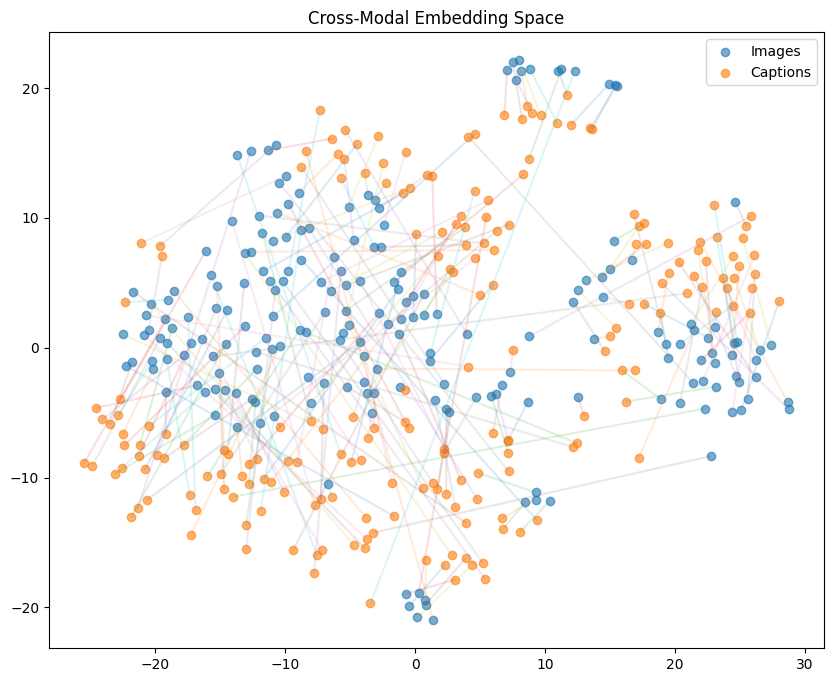

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Take first 200 test images and their first caption
n = 200

img_emb = image_embeddings[:n].numpy()

# first caption for each image
caption_emb = []

for image_name in test_image_names[:n]:
    row = test_df[test_df["image"] == image_name].iloc[0]

    tokens = torch.tensor(
        encode_caption(row["caption"]),
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_text(tokens)

    caption_emb.append(emb.cpu().numpy()[0])

caption_emb = np.array(caption_emb)

# Combine image + text embeddings
combined = np.vstack([img_emb, caption_emb])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

points = tsne.fit_transform(combined)

plt.figure(figsize=(10, 8))

plt.scatter(
    points[:n, 0],
    points[:n, 1],
    alpha=0.6,
    label="Images"
)

plt.scatter(
    points[n:, 0],
    points[n:, 1],
    alpha=0.6,
    label="Captions"
)

# connect matching image-caption pairs
for i in range(n):
    plt.plot(
        [points[i, 0], points[n+i, 0]],
        [points[i, 1], points[n+i, 1]],
        alpha=0.15
    )

plt.title("Cross-Modal Embedding Space")
plt.legend()
plt.show()

In [ ]:
def text_embedding(text):
    tokens = torch.tensor(
        encode_caption(text),
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        return model.encode_text(tokens).cpu()


pairs = [
    (
        "a dog is running through the grass",
        "a cat is running through the grass"
    ),
    (
        "a dog is running through the grass",
        "a dog is sleeping through the grass"
    ),
    (
        "a man is riding a bicycle",
        "a woman is riding a bicycle"
    )
]

for original, modified in pairs:

    e1 = text_embedding(original)
    e2 = text_embedding(modified)

    similarity = torch.nn.functional.cosine_similarity(
        e1,
        e2
    ).item()

    print("\nOriginal :", original)
    print("Modified :", modified)
    print(f"Cosine similarity: {similarity:.4f}")


Original : a dog is running through the grass
Modified : a cat is running through the grass
Cosine similarity: 0.5825

Original : a dog is running through the grass
Modified : a dog is sleeping through the grass
Cosine similarity: 0.7901

Original : a man is riding a bicycle
Modified : a woman is riding a bicycle
Cosine similarity: 0.8314


# CrossModal Alignment — Final Report

## 1. Problem Statement

The objective of this project is to learn a shared representation space for images and text. Matching image-caption pairs should have high similarity, while unrelated pairs should have lower similarity.

The learned representation is evaluated through:

- Image-to-text retrieval
- Text-to-image retrieval
- Cross-modal embedding visualization
- Semantic sensitivity analysis

---

## 2. Dataset

### Flickr8k

The Flickr8k dataset contains:

- 8,092 images
- 5 human-written captions per image
- 40,458 image-caption pairs

The standard image-level split was used:

| Split | Images | Captions |
|---|---:|---:|
| Train | 6,000 | 30,000 |
| Validation | 1,000 | 5,000 |
| Test | 1,000 | 5,000 |

The split was performed at the **image level**, ensuring that captions belonging to the same image were never distributed across different splits.

This prevents image-level information leakage between training and evaluation.

### Preprocessing

Captions were:

1. Converted to lowercase
2. Tokenized into words
3. Converted to integer token IDs
4. Limited to a maximum length of 25 tokens
5. Padded using a `<PAD>` token
6. Unknown words were mapped to `<UNK>`

A vocabulary of **7,560 words** was constructed from the training captions.

---

## 3. Model Architecture

The model maps both modalities into a shared **256-dimensional embedding space**.

### Image Representation

The Flickr8k dataset available for this experiment included precomputed 2,048-dimensional image representations.

These representations were used as the visual input.

The trainable image projection was:

```text
2048
  ↓
Linear(2048 → 512)
  ↓
ReLU
  ↓
Linear(512 → 256)
  ↓
L2 Normalization
  ↓
Image Embedding